In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

import os
from datetime import datetime


In [6]:
### read the raw data file
df_space = pd.read_csv("solar_data_2025.txt", sep=r'\s+', names=["year", "day", "hour", "Bz", "solar_density","solar_speed", "Kp_x10"])
df_space.head()

df_space = df_space.replace([999.9, 9999], np.nan)

In [7]:
combined_str = df_space['year'].astype(str) + '-' + df_space['day'].astype(str) + ' ' + df_space['hour'].astype(str)
df_space['time'] = pd.to_datetime(combined_str, format='%Y-%j %H')

# 4. Format the final output string to match your exact format (YYYY-MM-DDTHH:MM)
df_space['time'] = pd.to_datetime(combined_str, format='%Y-%j %H')

# df_space['time'] = datetime(df_space["time"])

print(df_space.tail(100))

      year  day  hour   Bz  solar_density  solar_speed  Kp_x10  \
8660  2025  361    20 -0.3            2.7        463.0      23   
8661  2025  361    21 -1.6            3.0        476.0      17   
8662  2025  361    22  0.5            3.0        479.0      17   
8663  2025  361    23 -1.8            3.2        479.0      17   
8664  2025  362     0 -0.1            2.9        465.0      20   
...    ...  ...   ...  ...            ...          ...     ...   
8755  2025  365    19  1.4            3.9        473.0      10   
8756  2025  365    20 -0.3            3.9        451.0      10   
8757  2025  365    21 -0.3            3.5        455.0      10   
8758  2025  365    22  2.1            3.4        457.0      10   
8759  2025  365    23  1.0            3.6        471.0      10   

                    time  
8660 2025-12-27 20:00:00  
8661 2025-12-27 21:00:00  
8662 2025-12-27 22:00:00  
8663 2025-12-27 23:00:00  
8664 2025-12-28 00:00:00  
...                  ...  
8755 2025-12-31 19

In [11]:
#chage it to your preference
lat = 45 
long = -93 
year = 2025

### Load aurora df
adf = pd.read_csv("web_observation_2014-08-01_to_2025-08-02_transformed.csv")
adf["st_yx"] = list(zip(adf['st_y'], adf['st_x'])) #(y,x) = (lat, long) so (x,y) = (long, lat)

In [ ]:
from geopy.distance import geodesic

target = (lat, long)  # (lat, lon)

adf["distance_km"] = adf.apply(
    lambda row: geodesic(
        (row["st_y"], row["st_x"]),
        target
    ).km,
    axis=1
)

nearby = adf[adf["distance_km"] <= 100]

print(nearby[["time_start", "time_end"]].tail())

nearby["time_start"] = pd.to_datetime(nearby["time_start"])
nearby["time_end"] = pd.to_datetime(nearby["time_end"])

nearby_2025 = nearby[
    (nearby["time_start"].dt.year == 2025) |
    (nearby["time_end"].dt.year == 2025)
]

if nearby_2025.shape[0] < 100:
    print("WARNING: Less than 100 observations, do you wanna go ahead?")

                      time_start                   time_end
28782  2025-06-01 07:15:00+00:00  2025-06-01 07:30:00+00:00
29028  2025-06-02 04:45:00+00:00  2025-06-02 05:00:00+00:00
29035  2025-06-02 05:00:00+00:00  2025-06-02 05:15:00+00:00
29457  2025-06-03 03:45:00+00:00  2025-06-03 04:00:00+00:00
29791  2025-07-06 06:15:00+00:00  2025-07-06 06:30:00+00:00


In [46]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": lat,
	"longitude": long,
	"start_date": "2025-01-04",
	"end_date": "2025-12-31",
	"hourly": ["cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high", "dew_point_2m", "precipitation", "relative_humidity_2m"],
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_cloud_cover = hourly.Variables(0).ValuesAsNumpy()
hourly_cloud_cover_low = hourly.Variables(1).ValuesAsNumpy()
hourly_cloud_cover_mid = hourly.Variables(2).ValuesAsNumpy()
hourly_cloud_cover_high = hourly.Variables(3).ValuesAsNumpy()
hourly_dew_point_2m = hourly.Variables(4).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(5).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(6).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["cloud_cover"] = hourly_cloud_cover
hourly_data["cloud_cover_low"] = hourly_cloud_cover_low
hourly_data["cloud_cover_mid"] = hourly_cloud_cover_mid
hourly_data["cloud_cover_high"] = hourly_cloud_cover_high
hourly_data["dew_point_2m"] = hourly_dew_point_2m
hourly_data["precipitation"] = hourly_precipitation
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m

df_weather = pd.DataFrame(data = hourly_data)

df_weather.to_csv(f"weather_data_{lat}_{long}.csv", index=False)


Coordinates: 45.02635955810547°N -92.93478393554688°E
Elevation: 311.0 m asl
Timezone difference to GMT+0: 0s


In [47]:
# keep only confirmed aurora sightings
#print(df_weather)

#df_weather = df_weather.rename(columns={"date": "time"})

df_weather = df_weather.rename(columns={"date": "time"})

df_weather["time"] = pd.to_datetime(df_weather["time"]).dt.tz_localize(None)

print(df_weather)

df_merged = pd.merge(df_space, df_weather, on="time", how="inner")

# df_merged has hourly UTC timestamps, but timezone-naive
df_merged["time"] = pd.to_datetime(df_merged["time"])

# keep only confirmed aurora sightings
sightings = nearby_2025[nearby_2025["see_aurora"] == True].copy()

# nearby_2025 has UTC timezone-aware timestamps, so make them timezone-naive UTC
sightings["time_start"] = pd.to_datetime(sightings["time_start"], utc=True).dt.tz_localize(None)
sightings["time_end"] = pd.to_datetime(sightings["time_end"], utc=True).dt.tz_localize(None)

# initialize label
df_merged["aurora"] = 0

# hourly bins: [time, time + 1 hour)
df_merged["hour_end"] = df_merged["time"] + pd.Timedelta(hours=1)

for _, row in sightings.iterrows():
    mask = (
        (df_merged["time"] < row["time_end"]) &
        (df_merged["hour_end"] > row["time_start"])
    )
    df_merged.loc[mask, "aurora"] = 1

df_merged = df_merged.drop(columns="hour_end")
df_merged["aurora"].value_counts()

                    time  cloud_cover  cloud_cover_low  cloud_cover_mid  \
0    2025-01-04 00:00:00          0.0              0.0              0.0   
1    2025-01-04 01:00:00          0.0              0.0              0.0   
2    2025-01-04 02:00:00          0.0              0.0              0.0   
3    2025-01-04 03:00:00          0.0              0.0              0.0   
4    2025-01-04 04:00:00          0.0              0.0              0.0   
...                  ...          ...              ...              ...   
8683 2025-12-31 19:00:00         99.0             97.0             85.0   
8684 2025-12-31 20:00:00        100.0            100.0             44.0   
8685 2025-12-31 21:00:00         98.0             98.0              0.0   
8686 2025-12-31 22:00:00         78.0             77.0              0.0   
8687 2025-12-31 23:00:00         64.0              7.0              0.0   

      cloud_cover_high  dew_point_2m  precipitation  relative_humidity_2m  
0                  0.0 

aurora
0    8612
1      76
Name: count, dtype: int64

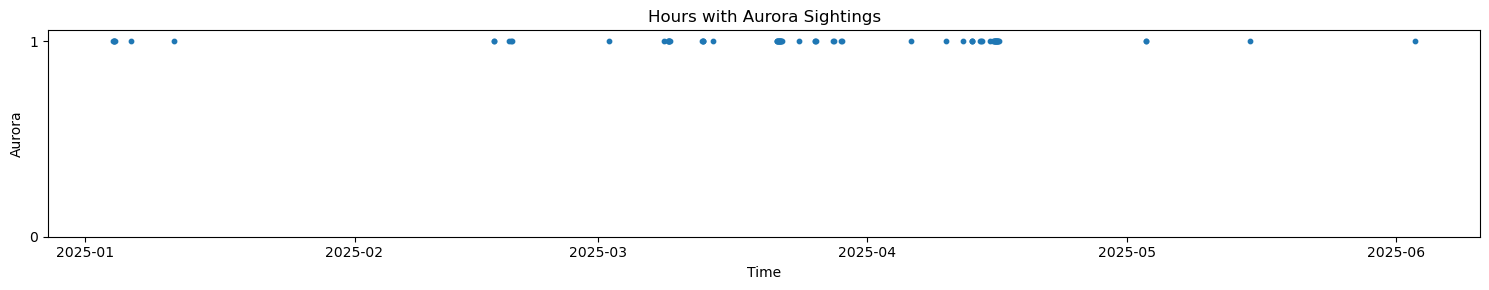

In [48]:
plt.figure(figsize=(15,3))

aurora_hours = df_merged[df_merged["aurora"] == 1]

plt.scatter(
    aurora_hours["time"],
    aurora_hours["aurora"],
    s=10
)

plt.xlabel("Time")
plt.ylabel("Aurora")
plt.yticks([0,1])
plt.title("Hours with Aurora Sightings")

plt.tight_layout()
plt.show()

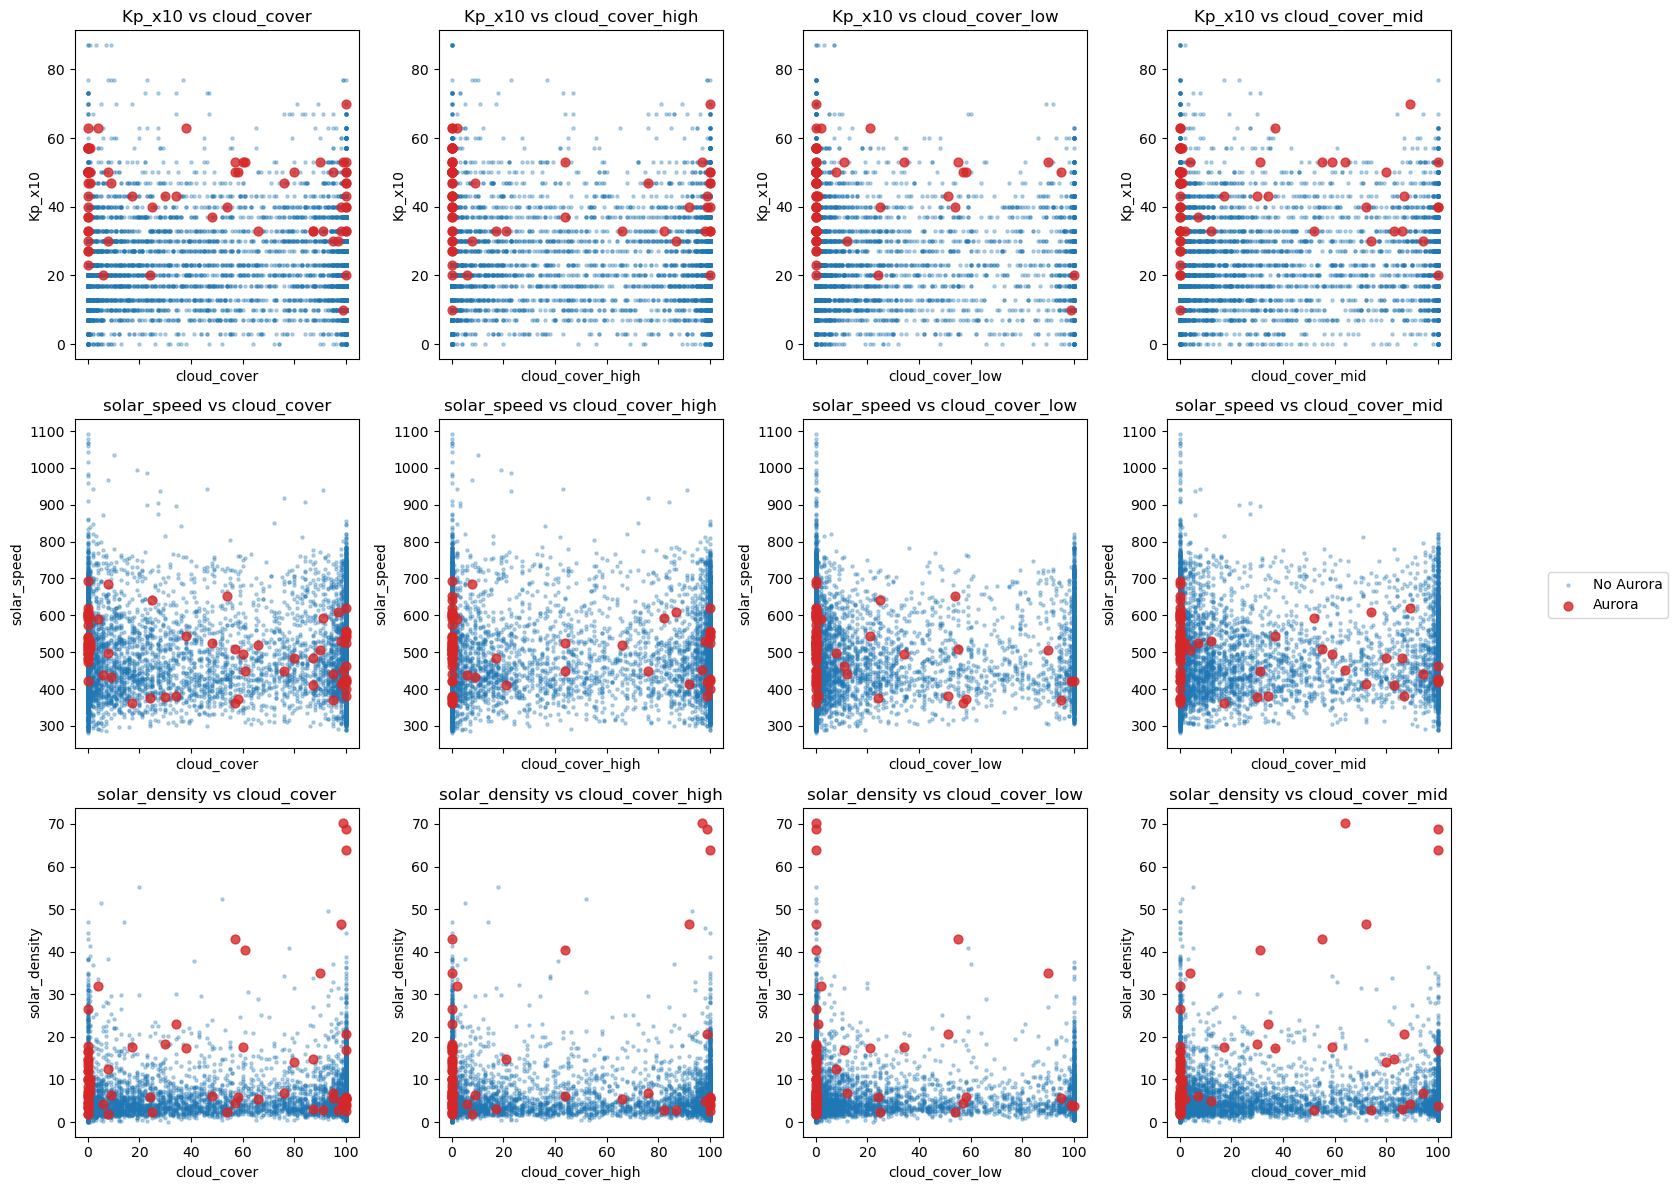

In [49]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

x_vars = ["cloud_cover","cloud_cover_high","cloud_cover_low","cloud_cover_mid"]
y_vars = ["Kp_x10", "solar_speed", "solar_density"]

fig, axes = plt.subplots(
    len(y_vars),
    len(x_vars),
    figsize=(len(x_vars)*4, len(y_vars)*4),
    sharex='col'
)

for i, y in enumerate(y_vars):
    for j, x in enumerate(x_vars):

        ax = axes[i, j]

        # Non-aurora points
        mask0 = df_merged["aurora"] == 0

        ax.scatter(
            df_merged.loc[mask0, x],
            df_merged.loc[mask0, y],
            color="tab:blue",
            alpha=0.3,
            s=5,
            label="No Aurora"
        )

        # Aurora points (larger)
        mask1 = df_merged["aurora"] == 1

        ax.scatter(
            df_merged.loc[mask1, x],
            df_merged.loc[mask1, y],
            color="tab:red",
            alpha=0.8,
            s=40,
            label="Aurora"
        )

        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"{y} vs {x}")

# Single legend instead of colorbar
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.05, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

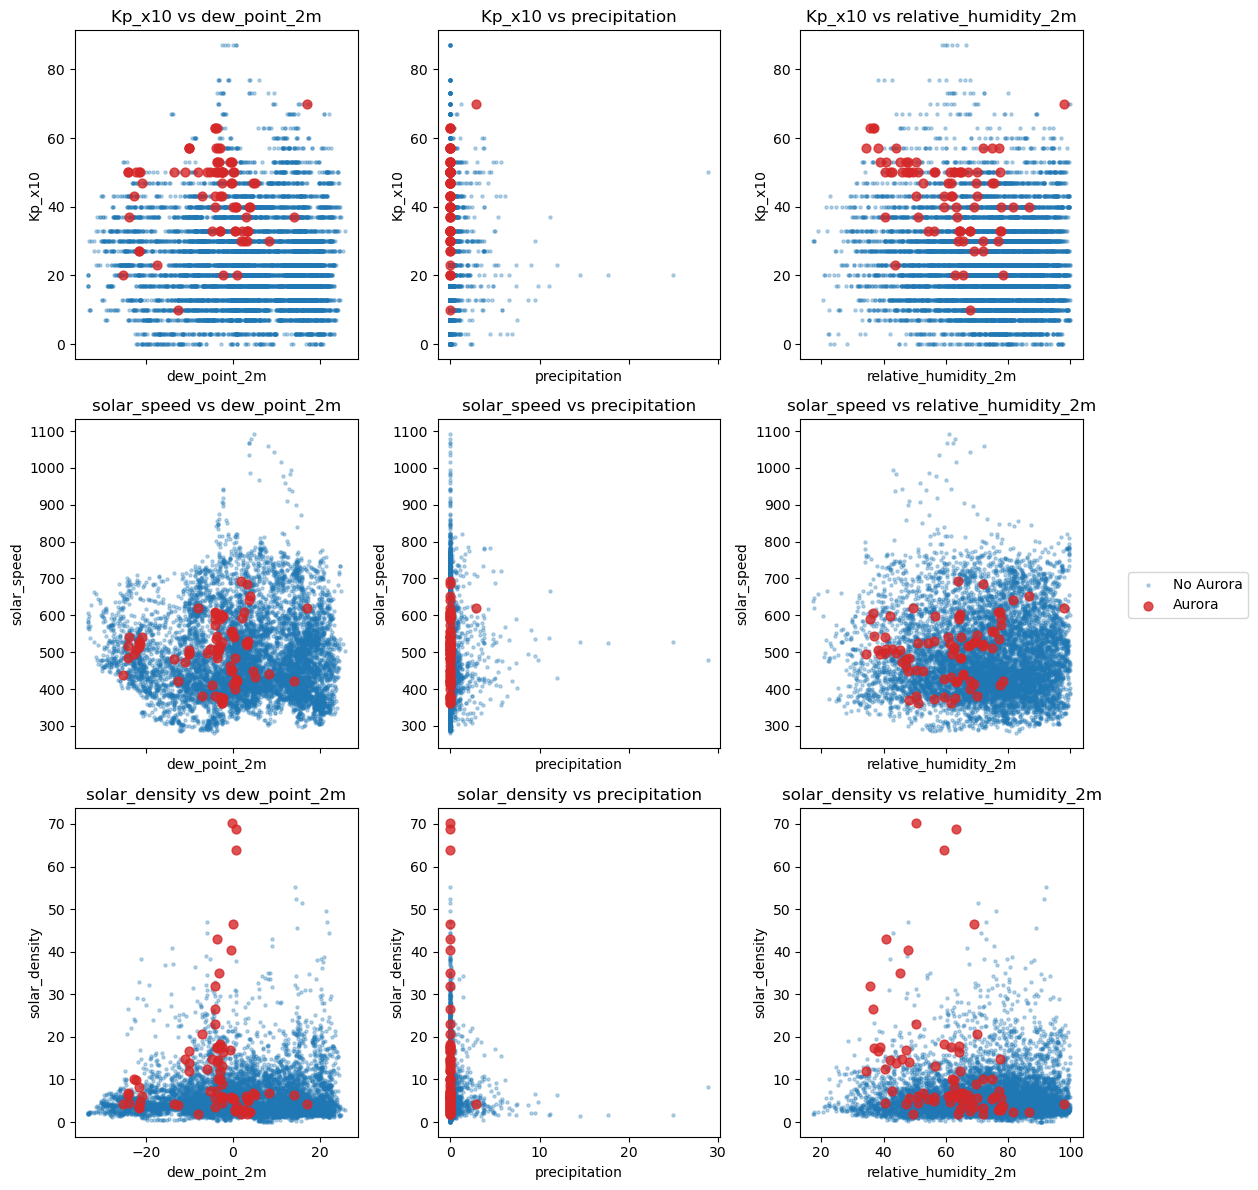

In [50]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

x_vars = ["dew_point_2m",  "precipitation"  ,"relative_humidity_2m"]
y_vars = ["Kp_x10", "solar_speed", "solar_density"]

fig, axes = plt.subplots(
    len(y_vars),
    len(x_vars),
    figsize=(len(x_vars)*4, len(y_vars)*4),
    sharex='col'
)

for i, y in enumerate(y_vars):
    for j, x in enumerate(x_vars):

        ax = axes[i, j]

        # Non-aurora points
        mask0 = df_merged["aurora"] == 0

        ax.scatter(
            df_merged.loc[mask0, x],
            df_merged.loc[mask0, y],
            color="tab:blue",
            alpha=0.3,
            s=5,
            label="No Aurora"
        )

        # Aurora points (larger)
        mask1 = df_merged["aurora"] == 1

        ax.scatter(
            df_merged.loc[mask1, x],
            df_merged.loc[mask1, y],
            color="tab:red",
            alpha=0.8,
            s=40,
            label="Aurora"
        )

        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"{y} vs {x}")
        # if x=="precipitation":
        #     ax.set_xlim(-0.1,0.1)

# Single legend instead of colorbar
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.05, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

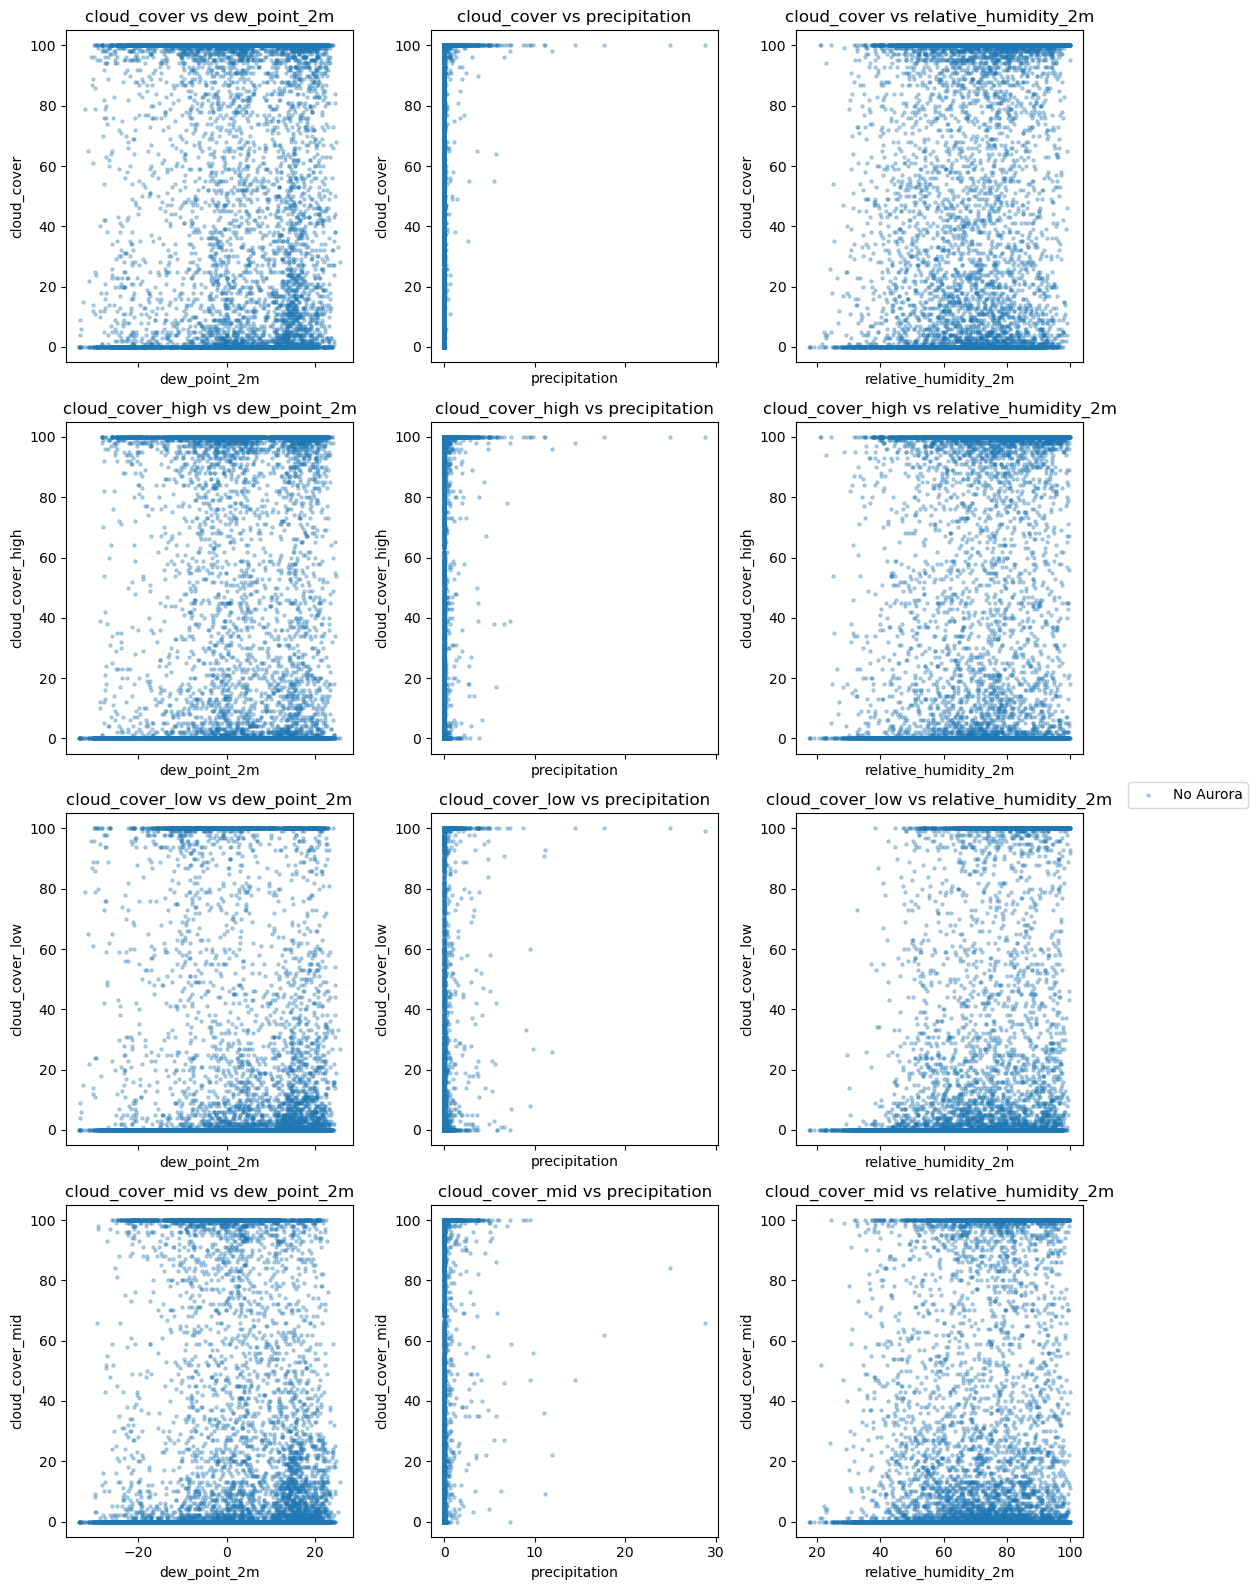

In [43]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

x_vars = ["dew_point_2m",  "precipitation"  ,"relative_humidity_2m"]
y_vars=["cloud_cover","cloud_cover_high","cloud_cover_low","cloud_cover_mid"]

fig, axes = plt.subplots(
    len(y_vars),
    len(x_vars),
    figsize=(len(x_vars)*4, len(y_vars)*4),
    sharex='col'
)

for i, y in enumerate(y_vars):
    for j, x in enumerate(x_vars):

        ax = axes[i, j]

        # Non-aurora points
        mask0 = df_merged["aurora"] != 2

        ax.scatter(
            df_merged.loc[mask0, x],
            df_merged.loc[mask0, y],
            color="tab:blue",
            alpha=0.3,
            s=5,
            label="No Aurora"
        )

        # Aurora points (larger)
        # mask1 = df_merged["aurora"] == 1

        # ax.scatter(
        #     df_merged.loc[mask1, x],
        #     df_merged.loc[mask1, y],
        #     color="tab:red",
        #     alpha=0.8,
        #     s=40,
        #     label="Aurora"
        # )

        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"{y} vs {x}")
        # if x=="precipitation":
        #     ax.set_xlim(-0.1,0.1)

# Single legend instead of colorbar
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.05, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()